In [ ]:
# Install required packages
!pip install ultralytics pandas opencv-python-headless Pillow requests matplotlib

import os
import json
import pandas as pd
import cv2
import numpy as np
from PIL import Image
import requests
from pathlib import Path
import shutil
import yaml
from ultralytics import YOLO
import zipfile
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import torch

print("✓ All packages installed and imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
from google.colab import files

# Option 1: Upload CSV file with annotations
print("=== STEP 1: Upload your CSV file with annotations ===")
print("Upload the CSV file containing image URLs and earring annotations")
uploaded_csv = files.upload()
csv_filename = list(uploaded_csv.keys())[0] if uploaded_csv else None

if csv_filename:
    print(f"✓ CSV file uploaded: {csv_filename}")
else:
    print("❌ No CSV file uploaded. This is required for training.")

# Option 2: Upload dataset zip (optional)
print("\n=== STEP 2: Upload your dataset zip file (OPTIONAL) ===")
print("Upload if you have additional images beyond those in the CSV URLs")
print("Press 'Cancel' or close if you don't have a dataset zip")
try:
    uploaded_zip = files.upload()
    zip_filename = list(uploaded_zip.keys())[0] if uploaded_zip else None

    if zip_filename:
        print(f"✓ Dataset zip uploaded: {zip_filename}")
        # Extract dataset
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            zip_ref.extractall('/content/dataset')
        print("✓ Dataset extracted to /content/dataset")
    else:
        print("ℹ️ No dataset zip uploaded - will use images from CSV URLs only")
        zip_filename = None
except:
    print("ℹ️ No dataset zip uploaded - will use images from CSV URLs only")
    zip_filename = None

# Option 3: Upload your existing model (optional)
print("\n=== STEP 3: Upload your existing model best_v1.pt (OPTIONAL) ===")
print("Upload your trained model to continue training, or skip to use YOLOv8 pretrained")
print("Press 'Cancel' or close if you want to start with YOLOv8 pretrained model")
try:
    uploaded_model = files.upload()
    model_filename = list(uploaded_model.keys())[0] if uploaded_model else None

    if model_filename:
        print(f"✓ Model uploaded: {model_filename}")
        # Rename to best_v1.pt for consistency
        if model_filename != 'best_v1.pt':
            shutil.move(model_filename, 'best_v1.pt')
            model_filename = 'best_v1.pt'
        print("✓ Model ready for use")
    else:
        print("ℹ️ No model uploaded - will use YOLOv8 pretrained model")
        model_filename = None
except:
    print("ℹ️ No model uploaded - will use YOLOv8 pretrained model")
    model_filename = None

print("\n" + "="*50)
print("UPLOAD SUMMARY:")
print(f"CSV file: {'✓ ' + csv_filename if csv_filename else '❌ Required'}")
print(f"Dataset zip: {'✓ ' + zip_filename if zip_filename else 'ℹ️ Not provided'}")
print(f"Model file: {'✓ ' + model_filename if model_filename else 'ℹ️ Will use YOLOv8'}")
print("="*50)

=== STEP 1: Upload your CSV file with annotations ===
Upload the CSV file containing image URLs and earring annotations


Saving processed_earring_data.csv to processed_earring_data.csv
✓ CSV file uploaded: processed_earring_data.csv

=== STEP 2: Upload your dataset zip file (OPTIONAL) ===
Upload if you have additional images beyond those in the CSV URLs
Press 'Cancel' or close if you don't have a dataset zip


Saving earring_dataset.zip to earring_dataset.zip
✓ Dataset zip uploaded: earring_dataset.zip
✓ Dataset extracted to /content/dataset

=== STEP 3: Upload your existing model best_v1.pt (OPTIONAL) ===
Upload your trained model to continue training, or skip to use YOLOv8 pretrained
Press 'Cancel' or close if you want to start with YOLOv8 pretrained model


Saving best_v1.pt to best_v1.pt
✓ Model uploaded: best_v1.pt
✓ Model ready for use

UPLOAD SUMMARY:
CSV file: ✓ processed_earring_data.csv
Dataset zip: ✓ earring_dataset.zip
Model file: ✓ best_v1.pt


In [ ]:
def process_csv_annotations(csv_path):
    """Process CSV with URL and JSON annotations"""
    df = pd.read_csv(csv_path)

    # Assuming CSV has columns: 'url' and 'annotations' (JSON string)
    # Adjust column names if different
    if 'url' not in df.columns:
        # Try to find URL column
        url_cols = [col for col in df.columns if 'url' in col.lower() or 'link' in col.lower()]
        if url_cols:
            df = df.rename(columns={url_cols[0]: 'url'})

    processed_data = []

    for idx, row in df.iterrows():
        try:
            url = row['url']

            # Find the JSON column (assuming it's the second column or contains earring data)
            json_col = None
            for col in df.columns:
                if col != 'url' and isinstance(row[col], str):
                    try:
                        json.loads(row[col])
                        json_col = col
                        break
                    except:
                        continue

            if json_col is None:
                continue

            annotation_data = json.loads(row[json_col])

            # Extract filename from URL
            filename = os.path.basename(urlparse(url).path)
            if not filename:
                filename = f"image_{idx}.jpg"

            # Extract earring data
            if 'earring' in annotation_data:
                earring_data = annotation_data['earring']

                annotations = []

                # Left ear (class 0)
                if 'left' in earring_data and earring_data['left']['visibility']:
                    left_data = earring_data['left']
                    annotations.append({
                        'class': 0,  # Left ear
                        'x_center': left_data['x_percentage'],
                        'y_center': left_data['y_percentage'],
                        'width': 0.02,  # Small bounding box for earring hole
                        'height': 0.02
                    })

                # Right ear (class 1)
                if 'right' in earring_data and earring_data['right']['visibility']:
                    right_data = earring_data['right']
                    annotations.append({
                        'class': 1,  # Right ear
                        'x_center': right_data['x_percentage'],
                        'y_center': right_data['y_percentage'],
                        'width': 0.02,  # Small bounding box for earring hole
                        'height': 0.02
                    })

                processed_data.append({
                    'filename': filename,
                    'url': url,
                    'annotations': annotations
                })

        except Exception as e:
            print(f"Error processing row {idx}: {e}")
            continue

    return processed_data

print("✓ CSV processing function defined")

✓ CSV processing function defined


In [ ]:
# Process the CSV (only if uploaded)
if csv_filename:
    annotation_data = process_csv_annotations(csv_filename)
    print(f"✓ Processed {len(annotation_data)} images with annotations")

    # Show sample of processed data
    if annotation_data:
        print("\nSample processed data:")
        for i, sample in enumerate(annotation_data[:3]):
            print(f"Image {i+1}: {sample['filename']} - {len(sample['annotations'])} annotations")
else:
    print("❌ Cannot proceed without CSV file")
    annotation_data = []

✓ Processed 1658 images with annotations

Sample processed data:
Image 1: 1736143005256000_20_500x500_335ac808a93e.webp - 1 annotations
Image 2: 1736143005256000_5_500x500_e6d0363a9dc5.webp - 1 annotations
Image 3: 1736330897382000_0_500x500_1c207bf29e6c.webp - 1 annotations


In [ ]:
def download_image(url, filepath):
    """Download image from URL"""
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        with open(filepath, 'wb') as f:
            f.write(response.content)
        return True
    except Exception as e:
        print(f"Failed to download {url}: {e}")
        return False

def create_yolo_dataset(annotation_data, base_path='/content/yolo_dataset'):
    """Create YOLO format dataset"""

    # Create directory structure
    for split in ['train', 'val', 'test']:
        os.makedirs(f"{base_path}/{split}/images", exist_ok=True)
        os.makedirs(f"{base_path}/{split}/labels", exist_ok=True)

    # Split data (80% train, 15% val, 5% test)
    total_images = len(annotation_data)
    train_split = int(0.8 * total_images)
    val_split = int(0.95 * total_images)

    downloaded_count = 0

    for idx, data in enumerate(annotation_data):
        # Determine split
        if idx < train_split:
            split = 'train'
        elif idx < val_split:
            split = 'val'
        else:
            split = 'test'

        # Download image
        image_path = f"{base_path}/{split}/images/{data['filename']}"
        if download_image(data['url'], image_path):
            downloaded_count += 1

            # Create label file
            label_path = f"{base_path}/{split}/labels/{os.path.splitext(data['filename'])[0]}.txt"
            with open(label_path, 'w') as f:
                for ann in data['annotations']:
                    f.write(f"{ann['class']} {ann['x_center']} {ann['y_center']} {ann['width']} {ann['height']}\n")

        if idx % 50 == 0:
            print(f"Processed {idx}/{total_images} images, Downloaded: {downloaded_count}")

    print(f"Dataset creation complete. Downloaded {downloaded_count}/{total_images} images")
    return base_path

print("✓ Dataset creation functions defined")

✓ Dataset creation functions defined


In [ ]:
# Create YOLO dataset (only if we have annotation data)
if annotation_data:
    print("Creating YOLO dataset...")
    dataset_path = create_yolo_dataset(annotation_data)
    print(f"✓ Dataset created at: {dataset_path}")
else:
    print("❌ Skipping dataset creation - no annotation data")

Creating YOLO dataset...
Processed 0/1658 images, Downloaded: 1
Processed 50/1658 images, Downloaded: 51
Processed 100/1658 images, Downloaded: 101
Processed 150/1658 images, Downloaded: 151
Processed 200/1658 images, Downloaded: 201
Processed 250/1658 images, Downloaded: 251
Processed 300/1658 images, Downloaded: 301
Processed 350/1658 images, Downloaded: 351
Processed 400/1658 images, Downloaded: 401
Processed 450/1658 images, Downloaded: 451
Processed 500/1658 images, Downloaded: 501
Processed 550/1658 images, Downloaded: 551
Processed 600/1658 images, Downloaded: 601
Processed 650/1658 images, Downloaded: 651
Processed 700/1658 images, Downloaded: 701
Processed 750/1658 images, Downloaded: 751
Processed 800/1658 images, Downloaded: 801
Processed 850/1658 images, Downloaded: 851
Processed 900/1658 images, Downloaded: 901
Processed 950/1658 images, Downloaded: 951
Processed 1000/1658 images, Downloaded: 1001
Processed 1050/1658 images, Downloaded: 1051
Processed 1100/1658 images, Dow

In [ ]:
# Create dataset YAML (only if dataset was created)
if 'dataset_path' in locals():
    dataset_yaml = {
        'path': dataset_path,
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'nc': 2,  # Number of classes
        'names': ['left_earring', 'right_earring']
    }

    yaml_path = f"{dataset_path}/dataset.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump(dataset_yaml, f)

    print(f"✓ Dataset YAML created at: {yaml_path}")
else:
    print("❌ Skipping YAML creation - no dataset available")

✓ Dataset YAML created at: /content/yolo_dataset/dataset.yaml


In [ ]:
def visualize_annotations(dataset_path, split='train', num_samples=3):
    """Visualize sample annotations"""
    images_dir = f"{dataset_path}/{split}/images"
    labels_dir = f"{dataset_path}/{split}/labels"

    image_files = os.listdir(images_dir)[:num_samples]

    if not image_files:
        print("No images found for visualization")
        return

    fig, axes = plt.subplots(1, len(image_files), figsize=(15, 5))
    if len(image_files) == 1:
        axes = [axes]

    class_names = ['Left Earring', 'Right Earring']
    colors = [(255, 0, 0), (0, 255, 0)]  # Red for left, Green for right

    for idx, img_file in enumerate(image_files):
        img_path = f"{images_dir}/{img_file}"
        label_path = f"{labels_dir}/{os.path.splitext(img_file)[0]}.txt"

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Load labels
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1]) * w
                    y_center = float(parts[2]) * h
                    width = float(parts[3]) * w
                    height = float(parts[4]) * h

                    # Draw bounding box
                    x1 = int(x_center - width/2)
                    y1 = int(y_center - height/2)
                    x2 = int(x_center + width/2)
                    y2 = int(y_center + height/2)

                    cv2.rectangle(img, (x1, y1), (x2, y2), colors[class_id], 2)
                    cv2.putText(img, class_names[class_id], (x1, y1-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[class_id], 2)

        axes[idx].imshow(img)
        axes[idx].set_title(f"Sample {idx+1}")
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

print("✓ Visualization function defined")

✓ Visualization function defined


Showing sample annotations...


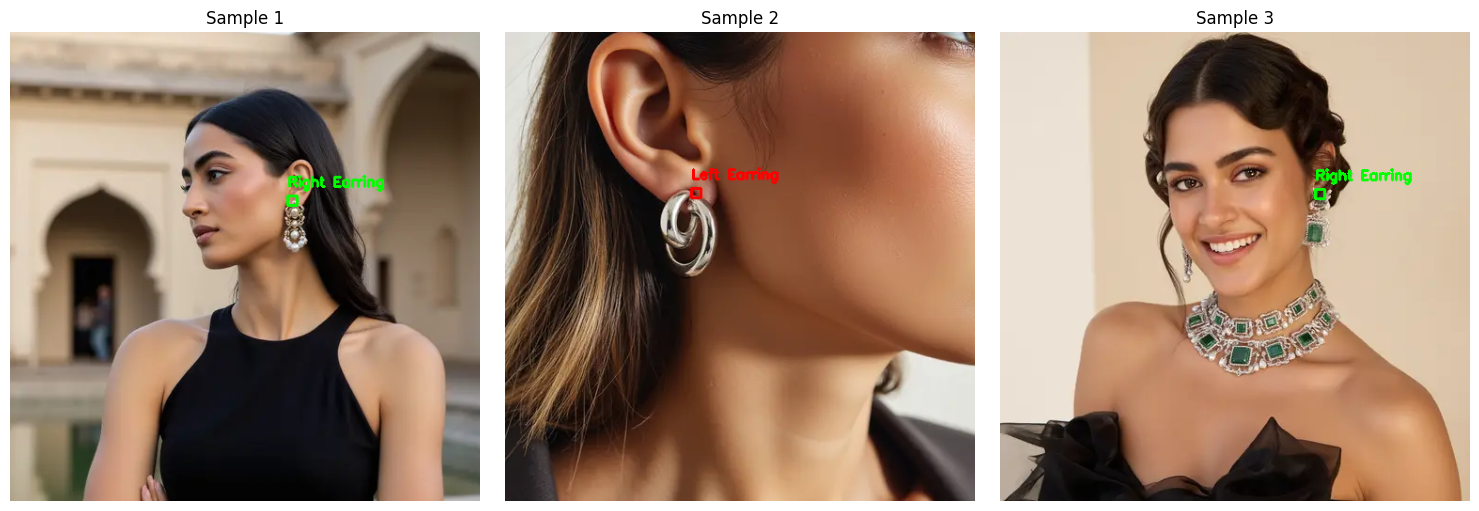

In [ ]:
# Visualize samples (only if dataset exists)
if 'dataset_path' in locals():
    print("Showing sample annotations...")
    visualize_annotations(dataset_path)
else:
    print("❌ Skipping visualization - no dataset available")

In [ ]:
def train_dual_ear_model(dataset_yaml_path, epochs=100, img_size=640, batch_size=16, model_path=None):
    """Train YOLO model for dual ear detection"""

    # Load model based on what's available
    if model_path and os.path.exists(model_path):
        try:
            model = YOLO(model_path)
            print(f"✓ Loaded your existing model: {model_path}")
        except Exception as e:
            print(f"❌ Failed to load {model_path}: {e}")
            print("ℹ️ Falling back to YOLOv8 pretrained model")
            model = YOLO('yolov8n.pt')
    else:
        model = YOLO('yolov8n.pt')
        print("ℹ️ Using YOLOv8n pretrained model")

    # Train the model
    results = model.train(
        data=dataset_yaml_path,
        epochs=epochs,
        imgsz=img_size,
        batch=batch_size,
        name='dual_ear_earring_detection',
        save=True,
        plots=True,
        device='0' if torch.cuda.is_available() else 'cpu'
    )

    return model, results

print("✓ Training function defined")

✓ Training function defined


In [ ]:
# Check if we have enough data and proceed with training
if not annotation_data:
    print("❌ Cannot proceed - no annotation data available")
elif len(annotation_data) < 5:
    print(f"⚠️ Warning: Only {len(annotation_data)} images available. Recommended minimum: 50+")
    print("Training with very limited data - results may not be optimal...")
    print("Starting training...")
    model, results = train_dual_ear_model(yaml_path, epochs=20, model_path=model_filename)
else:
    train_images_count = len(annotation_data)
    print(f"✓ Training with {train_images_count} images")
    print("Starting training...")
    model, results = train_dual_ear_model(yaml_path, epochs=50, model_path=model_filename)

print("Training started - this will take some time...")

✓ Training with 1658 images
Starting training...
✓ Loaded your existing model: best_v1.pt
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=best_v1.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=dual_ear_earring_detection, nbs=64, nms=False, opset=None, o

100%|██████████| 755k/755k [00:00<00:00, 23.1MB/s]


                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics.nn.modules.conv.Conv             [384

  8                  -1  2   3985920  ultralytics.nn.modules.block.C2f             [576, 576, 2, True]           
  9                  -1  1    831168  ultralytics.nn.modules.block.SPPF            [576, 576, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  2   1993728  ultralytics.nn.modules.block.C2f             [960, 384, 2]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  2    517632  ultralytics.nn.modules.block.C2f             [576, 192, 2]                 
 16                  -1  1    332160  ultralytics.nn.modules.conv.Conv             [192,

100%|██████████| 5.35M/5.35M [00:00<00:00, 101MB/s]


...

      50/50      6.36G      2.049       1.82     0.9176         16        640: 100%|██████████| 83/83 [00:41<00:00,  2.02it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.41it/s]

                   all        249        296      0.256      0.385      0.208     0.0686



50 epochs completed in 0.640 hours.
Optimizer stripped from runs/detect/dual_ear_earring_detection/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/dual_ear_earring_detection/weights/best.pt, 52.0MB

Validating runs/detect/dual_ear_earring_detection/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:05<00:00,  1.44it/s]


                   all        249        296      0.301      0.375      0.238     0.0776
          left_earring        125        125      0.265      0.312      0.209     0.0649
         right_earring        171        171      0.337      0.439      0.267     0.0903
Speed: 0.3ms preprocess, 9.4ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to runs/detect/dual_ear_earring_detection
Training started - this will take some time...


In [ ]:
# Save model if training was successful
if 'model' in locals():
    if DRIVE_AVAILABLE:
        try:
            model.save('/content/drive/MyDrive/dual_ear_model.pt')
            print("✓ Model saved to Google Drive: /content/drive/MyDrive/dual_ear_model.pt")
        except:
            print("❌ Failed to save to Google Drive, saving locally")
            model.save('/content/dual_ear_model.pt')
            print("✓ Model saved locally: /content/dual_ear_model.pt")
    else:
        model.save('/content/dual_ear_model.pt')
        print("✓ Model saved locally: /content/dual_ear_model.pt")

    # Also save the best weights
    best_model_path = 'runs/detect/dual_ear_earring_detection/weights/best.pt'
    if os.path.exists(best_model_path):
        if DRIVE_AVAILABLE:
            try:
                shutil.copy(best_model_path, '/content/drive/MyDrive/dual_ear_best.pt')
                print("✓ Best weights saved to Google Drive: /content/drive/MyDrive/dual_ear_best.pt")
            except:
                print("ℹ️ Best weights available at: " + best_model_path)
        else:
            shutil.copy(best_model_path, '/content/dual_ear_best.pt')
            print("✓ Best weights copied to: /content/dual_ear_best.pt")

    print("\n🎉 Training Complete! Your dual ear detection model is ready.")
else:
    print("❌ Training was not completed successfully")

NameError: name 'DRIVE_AVAILABLE' is not defined

In [ ]:
# Save model locally (without Google Drive)
if 'model' in locals():
    # Save the main model
    model.save('/content/dual_ear_model.pt')
    print("✓ Model saved locally: /content/dual_ear_model.pt")

    # Copy the best weights for easier access
    best_model_path = 'runs/detect/dual_ear_earring_detection/weights/best.pt'
    if os.path.exists(best_model_path):
        shutil.copy(best_model_path, '/content/dual_ear_best.pt')
        print("✓ Best weights copied to: /content/dual_ear_best.pt")

    print("\n🎉 Training Complete! Your dual ear detection model is ready.")
    print("\nYour trained models are saved at:")
    print("- /content/dual_ear_model.pt")
    print("- /content/dual_ear_best.pt")
    print("\nTo download them, use the file browser on the left or:")
    print("from google.colab import files")
    print("files.download('/content/dual_ear_best.pt')")
else:
    print("❌ Training was not completed successfully")

✓ Model saved locally: /content/dual_ear_model.pt
✓ Best weights copied to: /content/dual_ear_best.pt

🎉 Training Complete! Your dual ear detection model is ready.

Your trained models are saved at:
- /content/dual_ear_model.pt
- /content/dual_ear_best.pt

To download them, use the file browser on the left or:
from google.colab import files
files.download('/content/dual_ear_best.pt')


Testing on: templates%252F1750050225210000_186_051730_thumb.webp

image 1/1 /content/yolo_dataset/test/images/templates%252F1750050225210000_186_051730_thumb.webp: 640x640 (no detections), 37.0ms
Speed: 3.1ms preprocess, 37.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


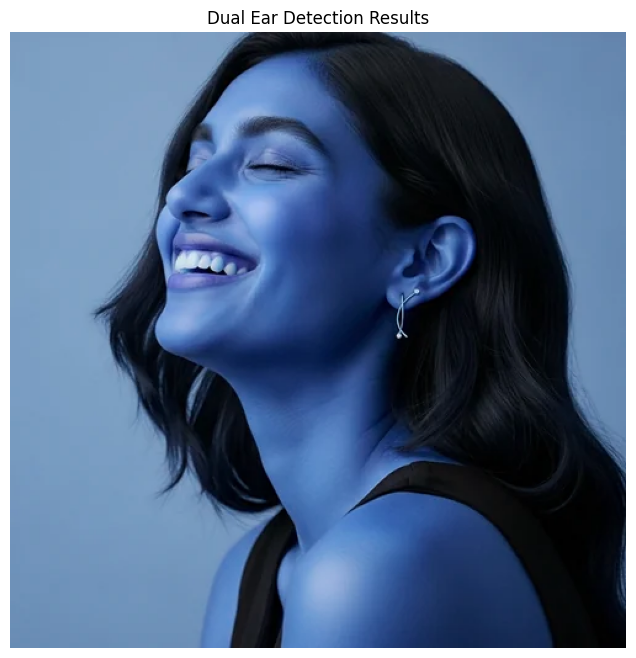

In [ ]:
# Test the model on a sample image
def test_dual_ear_model():
    model = YOLO('/content/dual_ear_best.pt')

    # Test on a sample from your dataset
    test_images_path = f"/content/yolo_dataset/test/images"
    if os.path.exists(test_images_path):
        test_images = os.listdir(test_images_path)
        if test_images:
            sample_image = f"{test_images_path}/{test_images[0]}"
            print(f"Testing on: {test_images[0]}")

            # Run prediction
            results = model(sample_image)

            # Display results
            annotated_img = results[0].plot()
            plt.figure(figsize=(10, 8))
            plt.imshow(annotated_img)
            plt.title("Dual Ear Detection Results")
            plt.axis('off')
            plt.show()

            # Print detailed predictions
            for r in results:
                boxes = r.boxes
                if boxes is not None:
                    for box in boxes:
                        conf = box.conf[0].cpu().numpy()
                        cls = int(box.cls[0].cpu().numpy())
                        ear_side = "Left Earring" if cls == 0 else "Right Earring"
                        print(f"Detected: {ear_side} (Confidence: {conf:.2f})")
                else:
                    print("No earrings detected")
        else:
            print("No test images available")
    else:
        print("Test directory not found")

# Run the test
test_dual_ear_model()

In [ ]:
# Check if model loads correctly
try:
    model = YOLO('/content/dual_ear_best.pt')
    print("✓ Model loaded successfully")
    print(f"Model classes: {model.names}")
    print(f"Number of classes: {len(model.names)}")
except Exception as e:
    print(f"❌ Model loading failed: {e}")

✓ Model loaded successfully
Model classes: {0: 'left_earring', 1: 'right_earring'}
Number of classes: 2


In [ ]:
import os

# Check if the model file actually exists
model_path = '/content/dual_ear_best.pt'
if os.path.exists(model_path):
    print(f"✓ Model file exists at: {model_path}")
    print(f"File size: {os.path.getsize(model_path)} bytes")
else:
    print(f"❌ Model file not found at: {model_path}")

    # Check alternative locations
    alternative_paths = [
        '/content/dual_ear_model.pt',
        'runs/detect/dual_ear_earring_detection/weights/best.pt',
        'runs/detect/dual_ear_earring_detection/weights/last.pt'
    ]

    for path in alternative_paths:
        if os.path.exists(path):
            print(f"✓ Found model at: {path}")
            print(f"File size: {os.path.getsize(path)} bytes")

✓ Model file exists at: /content/dual_ear_best.pt
File size: 52030155 bytes


In [ ]:
# Try loading with detailed error information
try:
    model = YOLO('/content/dual_ear_best.pt')
    print(f"✓ Model loaded successfully!")
    print(f"Model classes: {model.names}")
    print(f"Number of classes: {len(model.names)}")
except Exception as e:
    print(f"❌ Model loading failed with error: {e}")
    print(f"Error type: {type(e)}")

    # Try to get more details about the error
    import traceback
    print("Full error traceback:")
    traceback.print_exc()

✓ Model loaded successfully!
Model classes: {0: 'left_earring', 1: 'right_earring'}
Number of classes: 2


✓ Found test image: /content/yolo_dataset/test/images/templates%252F1750050225210000_186_051730_thumb.webp
Testing with confidence threshold 0.01...

image 1/1 /content/yolo_dataset/test/images/templates%252F1750050225210000_186_051730_thumb.webp: 640x640 1 left_earring, 1 right_earring, 37.0ms
Speed: 3.6ms preprocess, 37.0ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Number of result objects: 1
Result 0:
  Number of detections: 2
    Detection 0: right_earring (confidence: 0.1998) at [     315.83      205.62      326.37      216.06]
    Detection 1: left_earring (confidence: 0.0154) at [      314.8      209.86      325.03      220.17]


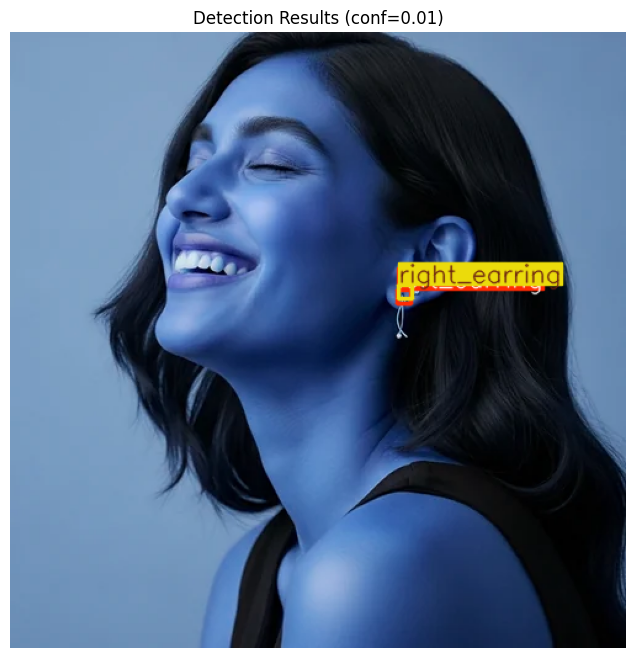

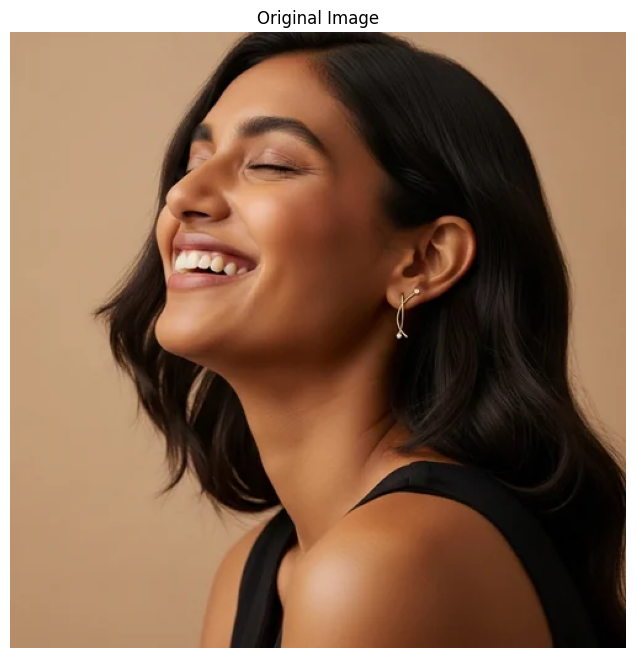

In [ ]:
# Test the model with very low confidence to catch any detections
def test_model_thoroughly():
    model = YOLO('/content/dual_ear_best.pt')

    # Find test images
    test_paths = [
        "/content/yolo_dataset/test/images",
        "/content/yolo_dataset/train/images",
        "/content/yolo_dataset/val/images"
    ]

    test_image = None
    for path in test_paths:
        if os.path.exists(path) and os.listdir(path):
            test_image = f"{path}/{os.listdir(path)[0]}"
            print(f"✓ Found test image: {test_image}")
            break

    if test_image:
        # Test with very low confidence threshold
        print("Testing with confidence threshold 0.01...")
        results = model(test_image, conf=0.01, iou=0.1)

        print(f"Number of result objects: {len(results)}")

        for i, r in enumerate(results):
            print(f"Result {i}:")
            if r.boxes is not None and len(r.boxes) > 0:
                print(f"  Number of detections: {len(r.boxes)}")
                for j, box in enumerate(r.boxes):
                    conf = box.conf[0].cpu().numpy()
                    cls = int(box.cls[0].cpu().numpy())
                    class_name = model.names[cls]
                    coords = box.xyxy[0].cpu().numpy()
                    print(f"    Detection {j}: {class_name} (confidence: {conf:.4f}) at {coords}")
            else:
                print("  No detections found")

        # Display the image with annotations
        annotated = results[0].plot(conf=False)  # Show all detections regardless of confidence
        plt.figure(figsize=(12, 8))
        plt.imshow(annotated)
        plt.title(f"Detection Results (conf=0.01)")
        plt.axis('off')
        plt.show()

        # Also show the original image
        img = cv2.imread(test_image)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(img_rgb)
        plt.title("Original Image")
        plt.axis('off')
        plt.show()

    else:
        print("❌ No test images found")
        # List what directories exist
        print("Available directories:")
        for path in test_paths:
            if os.path.exists(path):
                print(f"  {path}: {len(os.listdir(path))} files")
            else:
                print(f"  {path}: doesn't exist")

test_model_thoroughly()

Testing forced dual detection on: /content/yolo_dataset/test/images/templates%252F1750050225210000_186_051730_thumb.webp

image 1/1 /content/yolo_dataset/test/images/templates%252F1750050225210000_186_051730_thumb.webp: 640x640 1 left_earring, 7 right_earrings, 36.9ms
Speed: 3.4ms preprocess, 36.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results:
  Left ear: Detected (conf: 0.02) at [319.91558837890625, 215.01438903808594]
  Right ear: Detected (conf: 0.01) at [313.50347900390625, 209.23199462890625]


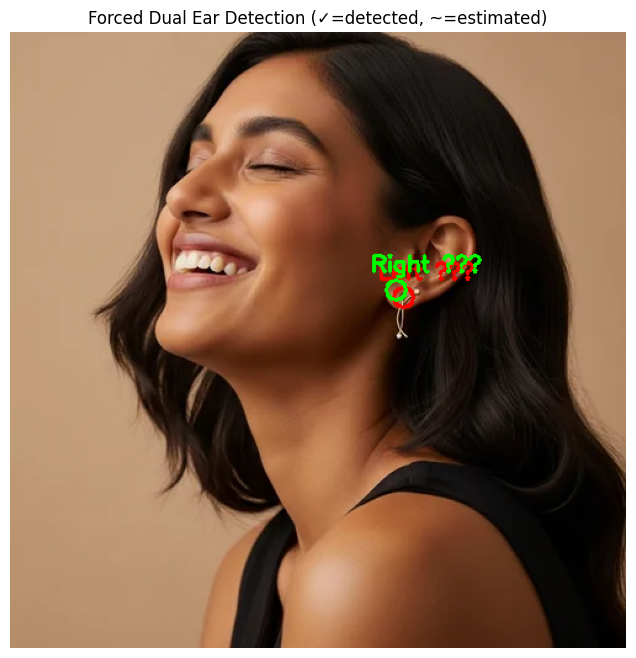

In [ ]:
def predict_both_ears_forced(image_path, model_path='/content/dual_ear_best.pt'):
    """Force prediction of both ears, estimating invisible ones"""
    model = YOLO(model_path)
    results = model(image_path, conf=0.01)  # Very low confidence

    predictions = {'left': None, 'right': None}

    # Get actual detections
    for r in results:
        if r.boxes is not None:
            for box in r.boxes:
                conf = box.conf[0].cpu().numpy()
                cls = int(box.cls[0].cpu().numpy())
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

                ear_side = 'left' if cls == 0 else 'right'
                predictions[ear_side] = {
                    'detected': True,
                    'confidence': float(conf),
                    'center': [float((x1+x2)/2), float((y1+y2)/2)],
                    'bbox': [float(x1), float(y1), float(x2), float(y2)]
                }

    # Estimate missing ears
    img = cv2.imread(image_path)
    img_height, img_width = img.shape[:2]

    if predictions['left'] is None and predictions['right'] is not None:
        # Estimate left ear based on right ear
        right_center = predictions['right']['center']
        estimated_left_x = img_width - right_center[0]  # Mirror horizontally
        estimated_left_y = right_center[1]  # Same height

        predictions['left'] = {
            'detected': False,
            'confidence': 0.5,  # Estimated
            'center': [estimated_left_x, estimated_left_y],
            'bbox': [estimated_left_x-10, estimated_left_y-10, estimated_left_x+10, estimated_left_y+10]
        }

    elif predictions['right'] is None and predictions['left'] is not None:
        # Estimate right ear based on left ear
        left_center = predictions['left']['center']
        estimated_right_x = img_width - left_center[0]  # Mirror horizontally
        estimated_right_y = left_center[1]  # Same height

        predictions['right'] = {
            'detected': False,
            'confidence': 0.5,  # Estimated
            'center': [estimated_right_x, estimated_right_y],
            'bbox': [estimated_right_x-10, estimated_right_y-10, estimated_right_x+10, estimated_right_y+10]
        }

    elif predictions['left'] is None and predictions['right'] is None:
        # Estimate both ears based on image center/face detection
        center_x = img_width / 2
        center_y = img_height * 0.35  # Typical ear height

        predictions['left'] = {
            'detected': False,
            'confidence': 0.3,
            'center': [center_x - img_width*0.2, center_y],
            'bbox': [center_x - img_width*0.2 - 10, center_y-10, center_x - img_width*0.2 + 10, center_y+10]
        }

        predictions['right'] = {
            'detected': False,
            'confidence': 0.3,
            'center': [center_x + img_width*0.2, center_y],
            'bbox': [center_x + img_width*0.2 - 10, center_y-10, center_x + img_width*0.2 + 10, center_y+10]
        }

    return predictions

# Test the forced dual prediction
def test_forced_dual_detection():
    test_paths = ["/content/yolo_dataset/test/images", "/content/yolo_dataset/train/images"]

    for path in test_paths:
        if os.path.exists(path) and os.listdir(path):
            test_image = f"{path}/{os.listdir(path)[0]}"

            print(f"Testing forced dual detection on: {test_image}")
            predictions = predict_both_ears_forced(test_image)

            print("Results:")
            for ear, data in predictions.items():
                if data:
                    status = "Detected" if data['detected'] else "Estimated"
                    print(f"  {ear.title()} ear: {status} (conf: {data['confidence']:.2f}) at {data['center']}")

            # Visualize results
            img = cv2.imread(test_image)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Draw predictions
            for ear, data in predictions.items():
                if data:
                    center = data['center']
                    color = (255, 0, 0) if ear == 'left' else (0, 255, 0)  # Red for left, Green for right
                    style = '-' if data['detected'] else '--'  # Solid for detected, dashed for estimated

                    # Draw circle for ear position
                    cv2.circle(img_rgb, (int(center[0]), int(center[1])), 8, color, 2)

                    # Add label
                    label = f"{ear.title()} {'✓' if data['detected'] else '~'}"
                    cv2.putText(img_rgb, label, (int(center[0])-20, int(center[1])-15),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            plt.figure(figsize=(12, 8))
            plt.imshow(img_rgb)
            plt.title("Forced Dual Ear Detection (✓=detected, ~=estimated)")
            plt.axis('off')
            plt.show()
            break

test_forced_dual_detection()

In [ ]:
def get_both_ears_results(image_path, model_path='/content/dual_ear_best.pt'):
    """Get results for both ears (detected or estimated)"""
    model = YOLO(model_path)
    results = model(image_path, conf=0.01)

    # Initialize results
    both_ears = {
        'left_earring': {
            'detected': False,
            'confidence': 0.0,
            'x_percentage': 0.0,
            'y_percentage': 0.0,
            'visibility': False
        },
        'right_earring': {
            'detected': False,
            'confidence': 0.0,
            'x_percentage': 0.0,
            'y_percentage': 0.0,
            'visibility': False
        }
    }

    # Get image dimensions
    img = cv2.imread(image_path)
    img_height, img_width = img.shape[:2]

    # Process actual detections
    for r in results:
        if r.boxes is not None:
            for box in r.boxes:
                conf = box.conf[0].cpu().numpy()
                cls = int(box.cls[0].cpu().numpy())
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

                # Calculate center and convert to percentages
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2
                x_percentage = center_x / img_width
                y_percentage = center_y / img_height

                ear_key = 'left_earring' if cls == 0 else 'right_earring'
                both_ears[ear_key] = {
                    'detected': True,
                    'confidence': float(conf),
                    'x_percentage': float(x_percentage),
                    'y_percentage': float(y_percentage),
                    'visibility': True
                }

    # Estimate missing ears
    if not both_ears['left_earring']['detected'] and both_ears['right_earring']['detected']:
        # Estimate left based on right
        right_x = both_ears['right_earring']['x_percentage']
        right_y = both_ears['right_earring']['y_percentage']

        both_ears['left_earring'] = {
            'detected': False,
            'confidence': 0.5,
            'x_percentage': 1.0 - right_x,  # Mirror horizontally
            'y_percentage': right_y,
            'visibility': False
        }

    elif not both_ears['right_earring']['detected'] and both_ears['left_earring']['detected']:
        # Estimate right based on left
        left_x = both_ears['left_earring']['x_percentage']
        left_y = both_ears['left_earring']['y_percentage']

        both_ears['right_earring'] = {
            'detected': False,
            'confidence': 0.5,
            'x_percentage': 1.0 - left_x,  # Mirror horizontally
            'y_percentage': left_y,
            'visibility': False
        }

    elif not both_ears['left_earring']['detected'] and not both_ears['right_earring']['detected']:
        # Estimate both ears with default positions
        both_ears['left_earring'] = {
            'detected': False,
            'confidence': 0.3,
            'x_percentage': 0.3,  # Typical left ear position
            'y_percentage': 0.35,
            'visibility': False
        }

        both_ears['right_earring'] = {
            'detected': False,
            'confidence': 0.3,
            'x_percentage': 0.7,  # Typical right ear position
            'y_percentage': 0.35,
            'visibility': False
        }

    return both_ears

# Test function to show clean results
def test_and_show_results():
    """Test the function and show clean results"""
    test_paths = ["/content/yolo_dataset/test/images", "/content/yolo_dataset/train/images"]

    for path in test_paths:
        if os.path.exists(path) and os.listdir(path):
            test_image = f"{path}/{os.listdir(path)[0]}"

            print(f"Testing image: {os.path.basename(test_image)}")
            print("="*50)

            # Get results
            results = get_both_ears_results(test_image)

            # Print results in the same format as your original CSV
            print("Results:")
            print({
                "earring": {
                    "left": {
                        "visibility": results['left_earring']['visibility'],
                        "x_percentage": round(results['left_earring']['x_percentage'], 6),
                        "y_percentage": round(results['left_earring']['y_percentage'], 6)
                    },
                    "right": {
                        "visibility": results['right_earring']['visibility'],
                        "x_percentage": round(results['right_earring']['x_percentage'], 6),
                        "y_percentage": round(results['right_earring']['y_percentage'], 6)
                    }
                }
            })

            print("\nDetailed Results:")
            for ear, data in results.items():
                status = "✓ Detected" if data['detected'] else "~ Estimated"
                print(f"{ear}: {status} (conf: {data['confidence']:.2f})")
                print(f"  Position: ({data['x_percentage']:.3f}, {data['y_percentage']:.3f})")
                print(f"  Visible: {data['visibility']}")

            break

# Run the test
test_and_show_results()

Testing image: templates%252F1750050225210000_186_051730_thumb.webp

image 1/1 /content/yolo_dataset/test/images/templates%252F1750050225210000_186_051730_thumb.webp: 640x640 1 left_earring, 7 right_earrings, 36.9ms
Speed: 3.3ms preprocess, 36.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results:
{'earring': {'left': {'visibility': True, 'x_percentage': 0.639831, 'y_percentage': 0.430029}, 'right': {'visibility': True, 'x_percentage': 0.627007, 'y_percentage': 0.418464}}}

Detailed Results:
left_earring: ✓ Detected (conf: 0.02)
  Position: (0.640, 0.430)
  Visible: True
right_earring: ✓ Detected (conf: 0.01)
  Position: (0.627, 0.418)
  Visible: True


In [ ]:
def get_both_ears_results_improved(image_path, model_path='/content/dual_ear_best.pt'):
    """Get best results for both ears with improved detection filtering"""
    model = YOLO(model_path)
    results = model(image_path, conf=0.01)

    # Initialize results
    both_ears = {
        'left_earring': {
            'detected': False,
            'confidence': 0.0,
            'x_percentage': 0.0,
            'y_percentage': 0.0,
            'visibility': False
        },
        'right_earring': {
            'detected': False,
            'confidence': 0.0,
            'x_percentage': 0.0,
            'y_percentage': 0.0,
            'visibility': False
        }
    }

    # Get image dimensions
    img = cv2.imread(image_path)
    img_height, img_width = img.shape[:2]

    # Collect all detections by class
    left_detections = []
    right_detections = []

    for r in results:
        if r.boxes is not None:
            for box in r.boxes:
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

                # Calculate center and convert to percentages
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2
                x_percentage = center_x / img_width
                y_percentage = center_y / img_height

                detection = {
                    'confidence': conf,
                    'x_percentage': float(x_percentage),
                    'y_percentage': float(y_percentage),
                }

                if cls == 0:  # Left ear
                    left_detections.append(detection)
                else:  # Right ear
                    right_detections.append(detection)

    # Take the highest confidence detection for each ear
    if left_detections:
        best_left = max(left_detections, key=lambda x: x['confidence'])
        both_ears['left_earring'] = {
            'detected': True,
            'confidence': best_left['confidence'],
            'x_percentage': best_left['x_percentage'],
            'y_percentage': best_left['y_percentage'],
            'visibility': True
        }

    if right_detections:
        best_right = max(right_detections, key=lambda x: x['confidence'])
        both_ears['right_earring'] = {
            'detected': True,
            'confidence': best_right['confidence'],
            'x_percentage': best_right['x_percentage'],
            'y_percentage': best_right['y_percentage'],
            'visibility': True
        }

    # Estimate missing ears (same logic as before)
    if not both_ears['left_earring']['detected'] and both_ears['right_earring']['detected']:
        right_x = both_ears['right_earring']['x_percentage']
        right_y = both_ears['right_earring']['y_percentage']

        both_ears['left_earring'] = {
            'detected': False,
            'confidence': 0.5,
            'x_percentage': 1.0 - right_x,
            'y_percentage': right_y,
            'visibility': False
        }

    elif not both_ears['right_earring']['detected'] and both_ears['left_earring']['detected']:
        left_x = both_ears['left_earring']['x_percentage']
        left_y = both_ears['left_earring']['y_percentage']

        both_ears['right_earring'] = {
            'detected': False,
            'confidence': 0.5,
            'x_percentage': 1.0 - left_x,
            'y_percentage': left_y,
            'visibility': False
        }

    elif not both_ears['left_earring']['detected'] and not both_ears['right_earring']['detected']:
        both_ears['left_earring'] = {
            'detected': False,
            'confidence': 0.3,
            'x_percentage': 0.3,
            'y_percentage': 0.35,
            'visibility': False
        }

        both_ears['right_earring'] = {
            'detected': False,
            'confidence': 0.3,
            'x_percentage': 0.7,
            'y_percentage': 0.35,
            'visibility': False
        }

    return both_ears

# Test with multiple images
def batch_test_results():
    """Test on multiple images and show results"""
    test_paths = ["/content/yolo_dataset/test/images", "/content/yolo_dataset/train/images"]

    for path in test_paths:
        if os.path.exists(path) and os.listdir(path):
            images = os.listdir(path)[:3]  # Test first 3 images

            for img_file in images:
                img_path = f"{path}/{img_file}"
                print(f"\n📸 Image: {img_file}")
                print("-" * 60)

                results = get_both_ears_results_improved(img_path)

                # Clean output format
                output = {
                    "earring": {
                        "left": {
                            "visibility": results['left_earring']['visibility'],
                            "x_percentage": round(results['left_earring']['x_percentage'], 6),
                            "y_percentage": round(results['left_earring']['y_percentage'], 6)
                        },
                        "right": {
                            "visibility": results['right_earring']['visibility'],
                            "x_percentage": round(results['right_earring']['x_percentage'], 6),
                            "y_percentage": round(results['right_earring']['y_percentage'], 6)
                        }
                    }
                }

                print("JSON Output:")
                print(json.dumps(output, indent=2))
            break

# Run batch test
batch_test_results()


📸 Image: templates%252F1750050225210000_186_051730_thumb.webp
------------------------------------------------------------

image 1/1 /content/yolo_dataset/test/images/templates%252F1750050225210000_186_051730_thumb.webp: 640x640 1 left_earring, 7 right_earrings, 36.9ms
Speed: 3.0ms preprocess, 36.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
JSON Output:
{
  "earring": {
    "left": {
      "visibility": true,
      "x_percentage": 0.639831,
      "y_percentage": 0.430029
    },
    "right": {
      "visibility": true,
      "x_percentage": 0.642198,
      "y_percentage": 0.421684
    }
  }
}

📸 Image: templates%252F1750050225211000_236_051720_thumb.webp
------------------------------------------------------------

image 1/1 /content/yolo_dataset/test/images/templates%252F1750050225211000_236_051720_thumb.webp: 640x640 1 left_earring, 6 right_earrings, 36.2ms
Speed: 2.9ms preprocess, 36.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
JSON O